# Healthcare: Medical Insurance Cost Prediction

# Exploratory Data Analysis (EDA) and Visualization

## Objectives
-	Understand data distribution
-	Identify relationships between variables
-	Detect outliers
-	Discover key drivers of insurance charges

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 2. import Dataset

In [5]:
df = pd.read_csv(r"C:\Users\User\Downloads\insurance.csv")

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.shape

(1338, 7)

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(1)

In [16]:
#remove duplicate records if any exist

df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

## 3. Understand the Dataset

| Variable | Description                              |
| -------- | ---------------------------------------- |
| age      | Age of beneficiary                       |
| sex      | Male/Female                              |
| bmi      | Body Mass Index                          |
| children | Number of dependents                     |
| smoker   | Smoking status                           |
| region   | Residential region                       |
| charges  | Medical insurance cost (Target Variable) |


## 4. Data Quality Checks

checking for null values

In [13]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['age', 'bmi', 'children', 'charges']

# 3. Age Analysis Visualization

### Objective
To understand how age influences medical insurance charges.

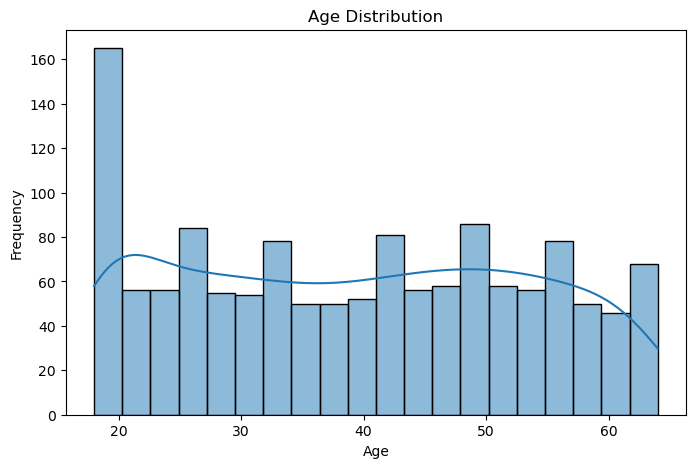

In [22]:
#Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## The population is fairly distributed across different age groups with a slight concentration among younger adults.

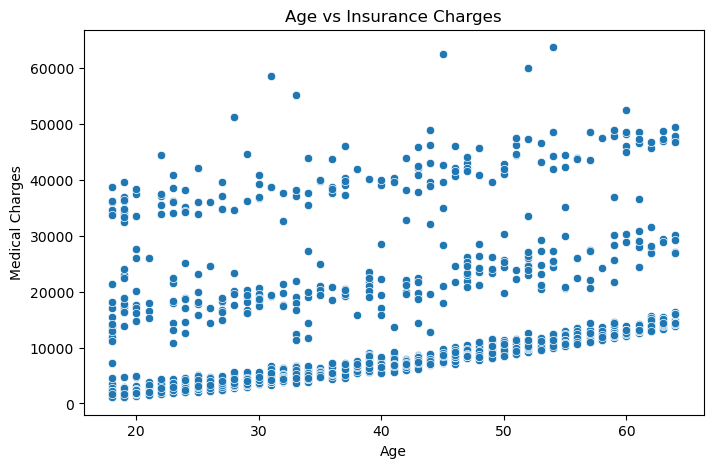

In [23]:
#Age vs Insurance Charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.show()

### Interpretation
-	The dataset contains individuals between ages 18 and 64. 
-	Most policyholders are concentrated between 20 and 50 years. 
-	Medical insurance charges generally increase with age. 
-	Older individuals tend to incur higher healthcare costs than younger individuals. 

### Key Finding
Age has a positive relationship with insurance charges, indicating that healthcare expenses increase as people grow older.


## 4. BMI Analysis Visualization

### Objective
To determine the effect of Body Mass Index (BMI) on insurance charges.


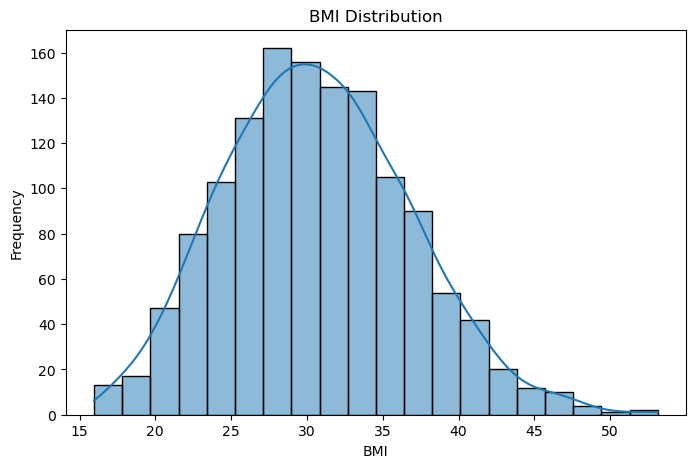

In [24]:
#BMI Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

Most policyholders have BMI levels indicating overweight conditions.

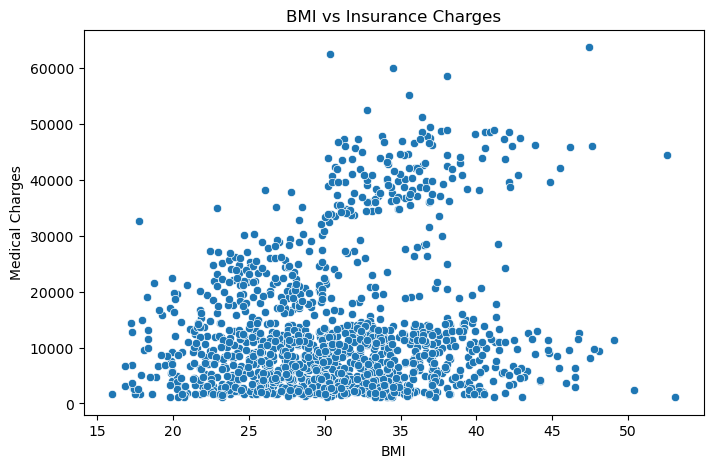

In [25]:
#BMI vs Charges

plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.show()

### Interpretation
-	BMI values are approximately normally distributed. 
-	Most individuals have BMI values between 25 and 35. 
-	Insurance charges tend to increase as BMI increases. 
-	Individuals with BMI above 30 generally have higher medical expenses. 

### Key Finding
BMI shows a positive correlation with insurance charges, suggesting that obesity-related health risks contribute to increased healthcare costs.


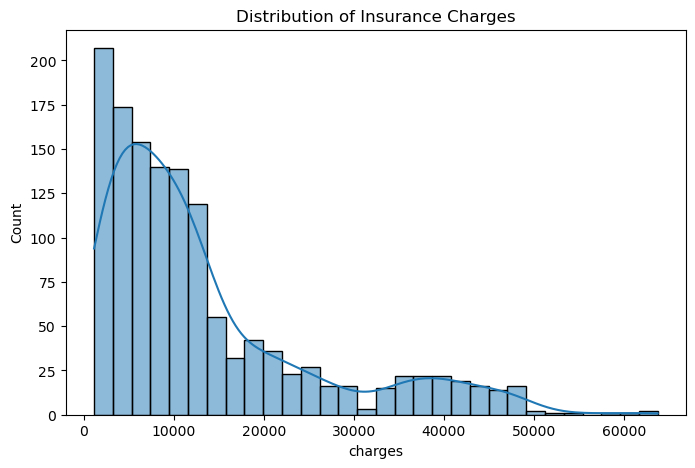

In [26]:
#Charges Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

The target variable is right-skewed, indicating a few individuals incur extremely high medical costs


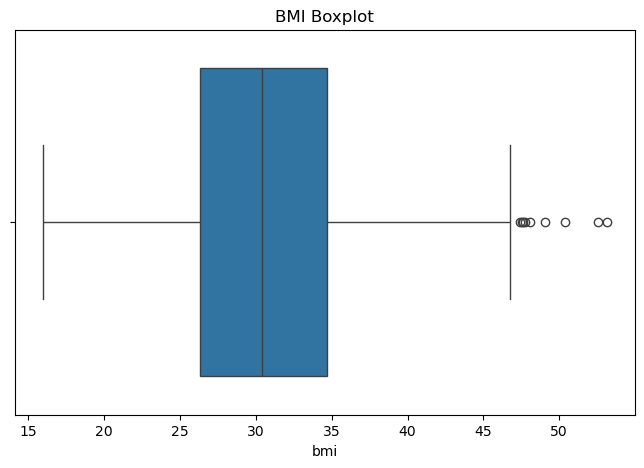

In [27]:
#Boxplot of BMI

plt.figure(figsize=(8,5))
sns.boxplot(x=df['bmi'])
plt.title('BMI Boxplot')
plt.show()

A few BMI outliers exist, representing individuals with exceptionally high body mass index values.

## 5. EDA Insights

### Summary of Findings
### Age
-	Age is positively correlated with medical insurance charges. 
-	Older individuals generally pay higher insurance costs. 
-	Healthcare expenses increase progressively with age. 
### BMI
-	BMI is positively associated with insurance charges. 
-	Individuals with higher BMI values tend to incur larger medical expenses. 
-	Obesity appears to be an important factor affecting healthcare costs. 
### Distribution of Charges
-	Insurance charges are highly skewed. 
-	A small number of policyholders generate very high medical costs. 
### Business Implications
i.	 Age significantly influences healthcare expenditure and should be retained as a key predictive feature.

ii.	 BMI contributes meaningfully to medical costs and should be included in predictive models.

iii. Insurance providers can use age and BMI information to better estimate future healthcare expenses.

iv.	 Preventive health programs targeting obesity may help reduce long-term medical costs.